In [1]:
!mamba install pandas
%pip install pandas matplotlib numpy seaborn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.58189999999851 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.3    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.2   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge
mambajs 0.21.1

Process pip requirements ...

Requirement pandas already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.
Requirement numpy already handled by conda/micromamba/mamba.
Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [3]:

cleaned_data = pd.read_csv(
    'Cleaned_Data/202601-202603_cleaned_cyclisticfull.csv', index_col=0)
cleaned_data.head()

,index,BikeType,RideStart,RideTime[s],Weekday,RideEnd,StartStation,EndStation,MemberType
39256,39256,classic_bike,2025-12-31 10:30:49.482,0 days 14:26:57,2,2026-01-01 00:57:46.690,Broadway & Barry Ave,Southport Ave & Wellington Ave,casual
50680,50680,classic_bike,2025-12-31 18:36:46.830,0 days 20:31:21,2,2026-01-01 15:08:08.579,Morgan St & 18th St,Archer Ave & Wentworth Ave,member
18778,18778,classic_bike,2025-12-31 19:49:01.401,0 days 19:19:07,2,2026-01-01 15:08:08.579,Calumet Ave & 18th St,Archer Ave & Wentworth Ave,member
12038,12038,classic_bike,2025-12-31 23:31:12.103,0 days 02:55:11,2,2026-01-01 02:26:23.361,Canal St & Madison St,Sedgwick St & Schiller St,casual
1610,1610,classic_bike,2025-12-31 23:36:22.998,0 days 01:02:47,2,2026-01-01 00:39:10.110,DuSable Lake Shore Dr & North Blvd,DuSable Lake Shore Dr & North Blvd,casual


In [4]:

cleaned_data = pd.read_csv(
    'Cleaned_Data/202601-202603_cleaned_cyclisticfull.csv', index_col=0)
cleaned_data.head()

,index,BikeType,RideStart,RideTime[s],Weekday,RideEnd,StartStation,EndStation,MemberType
39256,39256,classic_bike,2025-12-31 10:30:49.482,0 days 14:26:57,2,2026-01-01 00:57:46.690,Broadway & Barry Ave,Southport Ave & Wellington Ave,casual
50680,50680,classic_bike,2025-12-31 18:36:46.830,0 days 20:31:21,2,2026-01-01 15:08:08.579,Morgan St & 18th St,Archer Ave & Wentworth Ave,member
18778,18778,classic_bike,2025-12-31 19:49:01.401,0 days 19:19:07,2,2026-01-01 15:08:08.579,Calumet Ave & 18th St,Archer Ave & Wentworth Ave,member
12038,12038,classic_bike,2025-12-31 23:31:12.103,0 days 02:55:11,2,2026-01-01 02:26:23.361,Canal St & Madison St,Sedgwick St & Schiller St,casual
1610,1610,classic_bike,2025-12-31 23:36:22.998,0 days 01:02:47,2,2026-01-01 00:39:10.110,DuSable Lake Shore Dr & North Blvd,DuSable Lake Shore Dr & North Blvd,casual


In [5]:
# Color palette for weekdays plots - from dark to bright:
colors_w = ('#3f94a4', '#3aa7ab', '#45baac',
          '#60cba6', '#84db9c', '#aee991', '#dcf587')
def_color = colors_w[0]
# Fonts:
font1 = {'color': 'black', 'fontweight': 'bold', 'size': 14}
font2 = {'color': 'black', 'fontweight': 'bold', 'size': 10}


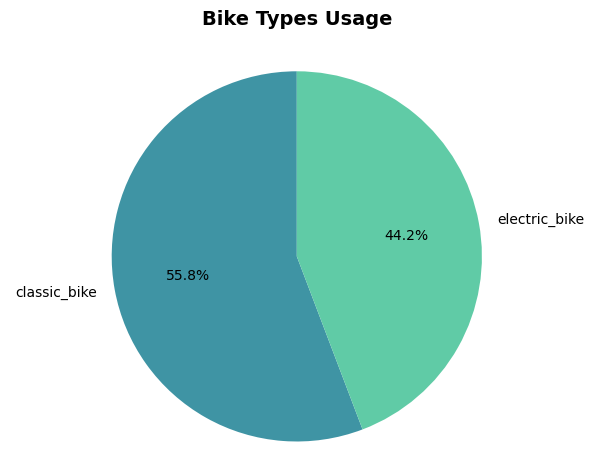

In [6]:
# Overall bike type usage:
bike_type_usage_overall = cleaned_data.BikeType.value_counts()
btus_y = np.array([bike_type_usage_overall]).flatten()
btus_labels = ['classic_bike',
               'electric_bike']

plt.pie(btus_y, labels=btus_labels,
        startangle=90, autopct='%.1f%%', colors=(colors_w[0], 
        colors_w[3], colors_w[5]))
plt.title("Bike Types Usage", fontdict=font1, pad=20)
plt.axis('equal')
plt.tight_layout()



(0.0, 200000.0)

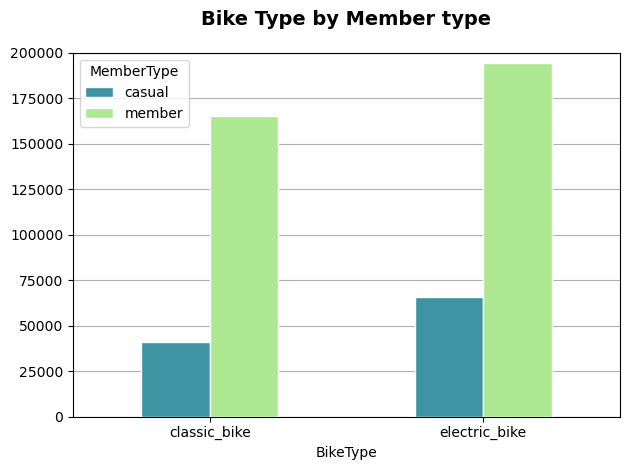

In [7]:

# Bike type used by user type:
bike_usage_by_user = cleaned_data[['BikeType', 'MemberType']].copy()
bubu = bike_usage_by_user.value_counts()

fig, ax = plt.subplots()
bubu.unstack().plot.bar(ax=ax, rot=0, color=(colors_w[0], colors_w[5]), zorder=3, edgecolor='w')
plt.title("Bike Type by Member type", fontdict=font1, pad=20)
plt.grid(axis='y', zorder=0)
plt.tight_layout()
plt.ylim(0, 2e5)


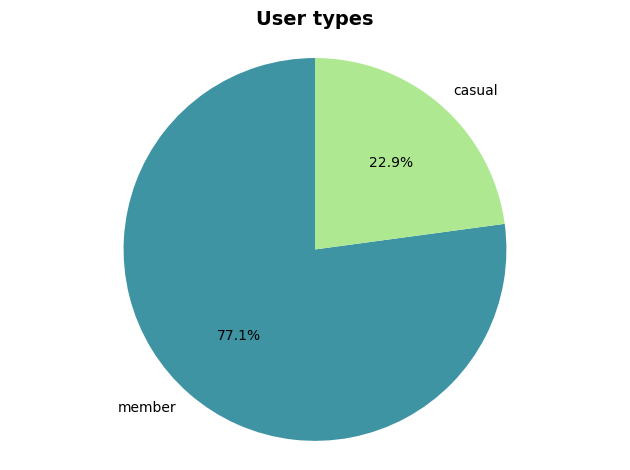

In [8]:

# Overall usage by user:
overall_usage_by_user = cleaned_data['MemberType'].copy()
oubu = overall_usage_by_user.value_counts()

oubu_labels = ['member',
               'casual']
plt.pie(oubu, labels=oubu_labels,
        startangle=90, autopct='%.1f%%', colors=(colors_w[0], colors_w[5]))
plt.title("User types", fontdict=font1, pad=10)
plt.axis('equal')
plt.tight_layout()




--- Check your Weekday values ---
Weekday
Monday       75734
Sunday       75646
Tuesday      70541
Wednesday    70193
Thursday     65849
Friday       58937
Saturday     49740
Name: count, dtype: int64
---------------------------------
--- Final Plot Matrix Data ---
Weekday        Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
BikeType                                                                     
classic_bike    32572    30600      29927     28361   27336     23188   34364
electric_bike   43162    39941      40266     37488   31601     26552   41282
------------------------------


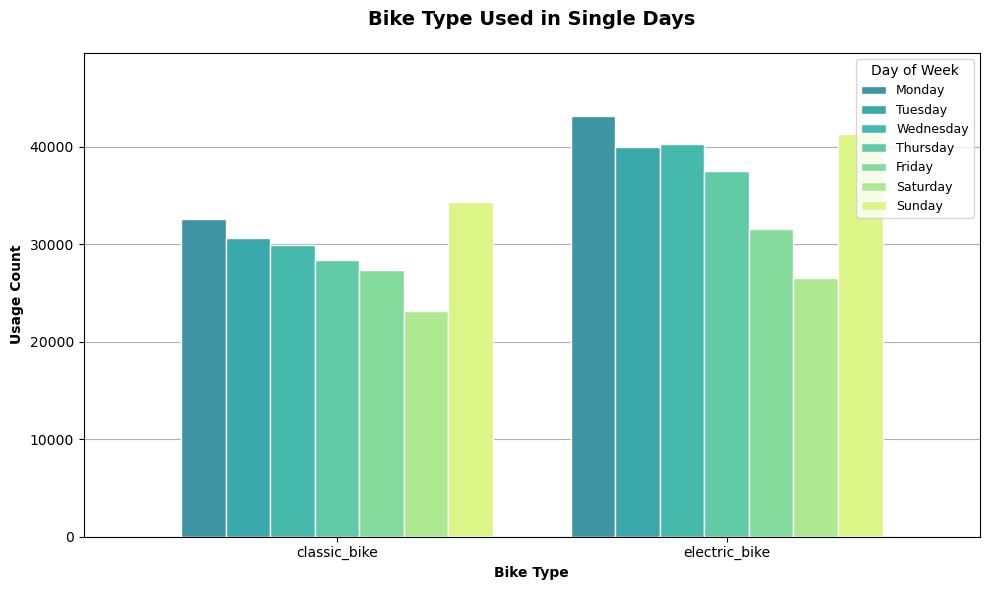

In [9]:
# 1. Full categorical order
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Make a clean copy
bike_usage_by_weekday = cleaned_data[['BikeType', 'Weekday']].copy()

# --- THE UNIVERSAL TRANSLATOR FIX ---
# Force to string, clean spaces, and make title case
bike_usage_by_weekday['Weekday'] = bike_usage_by_weekday['Weekday'].astype(str).str.strip().str.title()

# Map short abbreviations or numbers to full day names if they exist
day_mapping = {
    'Mon': 'Monday', 'Tue': 'Tuesday', 'Wed': 'Wednesday', 'Thu': 'Thursday', 'Fri': 'Friday', 'Sat': 'Saturday', 'Sun': 'Sunday',
    '1': 'Monday', '2': 'Tuesday', '3': 'Wednesday', '4': 'Thursday', '5': 'Friday', '6': 'Saturday', '7': 'Sunday',
    '0': 'Sunday' # Some systems count Sunday as 0
}
bike_usage_by_weekday['Weekday'] = bike_usage_by_weekday['Weekday'].replace(day_mapping)

# --- DIAGNOSTIC PRINT ---
# This will show you exactly what values are in your column right now. 
# Look closely at this output in your terminal!
print("--- Check your Weekday values ---")
print(bike_usage_by_weekday['Weekday'].value_counts())
print("---------------------------------")

# Now it is completely safe to enforce the category without warnings
bike_usage_by_weekday['Weekday'] = pd.Categorical(
    bike_usage_by_weekday['Weekday'], 
    categories=days, 
    ordered=True
)

# 3. Aggregate data
bubw = bike_usage_by_weekday.value_counts().unstack('Weekday').fillna(0)

print("--- Final Plot Matrix Data ---")
print(bubw)
print("------------------------------")

# 4. Plotting Execution
fig, ax = plt.subplots(figsize=(10, 6))

# Let's make sure colors_w matches whatever your list name is
bubw.plot.bar(ax=ax, rot=0, width=0.8, color=colors_w, zorder=3, edgecolor='w')

ax.grid(axis='y', zorder=0)
plt.title("Bike Type Used in Single Days", fontdict=font1, pad=20)
plt.xlabel("Bike Type", fontdict=font2)
plt.ylabel("Usage Count", fontdict=font2)

# Dynamically scale instead of a hard limit, just in case 1e5 is too small or too large
if not bubw.empty:
    plt.ylim(0, bubw.values.max() * 1.15)

plt.legend(title="Day of Week", loc='upper right', prop={'size': 9}, facecolor='white')
plt.tight_layout()

plt.show()

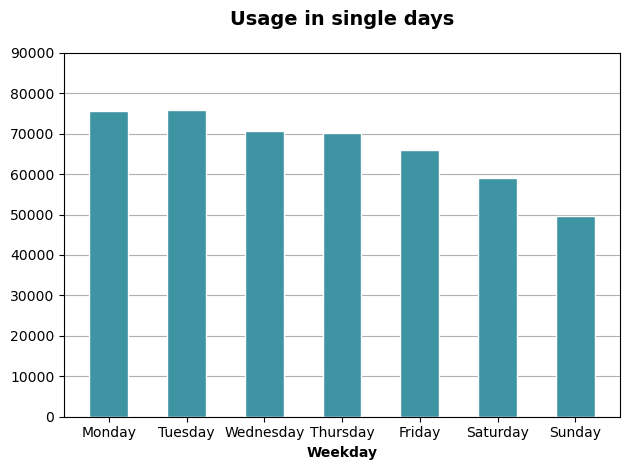

In [10]:

# Most usage by days
usage_by_weekday = cleaned_data['Weekday'].copy()
ubw = usage_by_weekday.value_counts().sort_index()
plt.bar(days, height=ubw, width=0.5, color=def_color, zorder=4, edgecolor='w')
plt.grid(axis='y', zorder=0)
plt.xlabel("Weekday", fontdict=font2)
plt.title("Usage in single days", fontdict=font1, pad=20)
plt.ylim(0, 9e4)
plt.tight_layout()



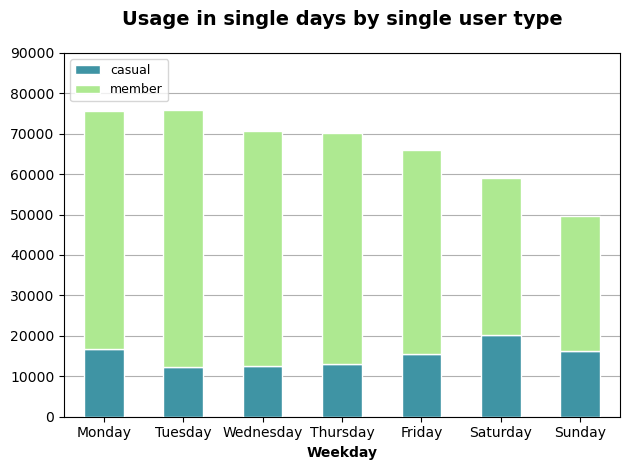

In [11]:

# Most usage by days & user type
usage_by_weekday_user = cleaned_data[['Weekday', 'MemberType']].copy()
ubwu = usage_by_weekday_user.value_counts().sort_index()

ubwu_plot = ubwu.unstack().plot.bar(
    rot=0, color=(colors_w[0], colors_w[5]), stacked=True, zorder=3, edgecolor='w')
plt.grid(axis='y', zorder=0)
plt.xlabel("Weekday", fontdict=font2)
index = range(len(days))
plt.title("Usage in single days by single user type", fontdict=font1, pad=20)
plt.xticks(index, days)
plt.ylim(0, 9e4)
plt.tight_layout()
plt.legend(loc='upper left', prop={'size': 9}, facecolor='white')


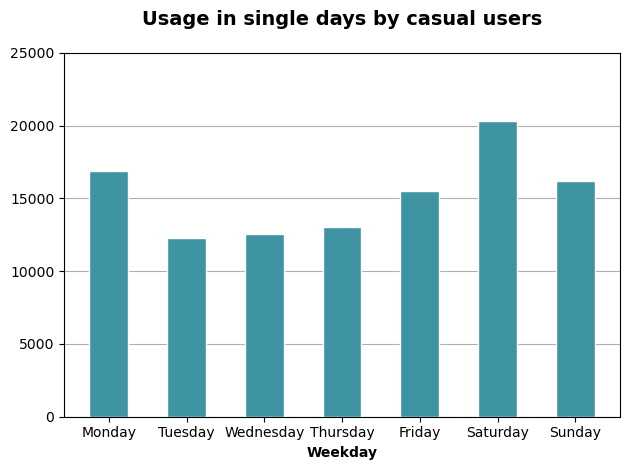

In [12]:
# Most usage in single days by casual users
usage_days_casual = usage_by_weekday_user[usage_by_weekday_user['MemberType'] == 'casual']
uc = usage_days_casual.value_counts().sort_index()
plt.bar(days, height=uc, width=0.5, color=def_color, zorder=3, edgecolor='w')
plt.grid(axis='y', zorder=0)
plt.ylim(0, 2.5e4)
plt.xlabel("Weekday", fontdict=font2)
plt.title("Usage in single days by casual users", fontdict=font1, pad=20)
plt.xticks(index, days)
plt.tight_layout()



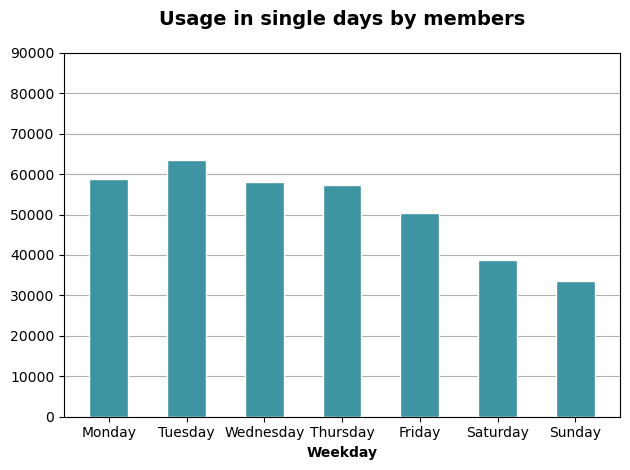

In [13]:

# Most usage in single days by members
usage_days_member = usage_by_weekday_user[usage_by_weekday_user['MemberType'] == 'member']
um = usage_days_member.value_counts().sort_index()
plt.bar(days, height=um, width=0.5, color=def_color, zorder=3, edgecolor='w')
plt.grid(axis='y', zorder=0)
plt.ylim(0, 9e4)
plt.xlabel("Weekday", fontdict=font2)
plt.title("Usage in single days by members", fontdict=font1, pad=20)
plt.xticks(index, days)
plt.tight_layout()



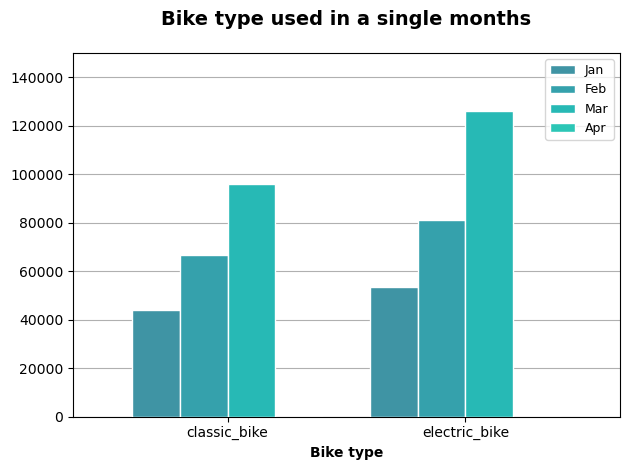

In [14]:

# Bike type used in single months:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors_m = ('#3f94a4', '#35a1ac', '#27b9b5', '#2cc6b6', '#3bd2b4', '#4fddb0', '#69e3a8',
            '#82e7a0', '#99eb98', '#afef91', '#c6f28b', '#dcf587')

bike_usage_by_month = cleaned_data[['BikeType', 'RideStart']].copy()
bike_usage_by_month['Month'] = pd.DatetimeIndex(bike_usage_by_month['RideStart']).month
bubm = bike_usage_by_month[['BikeType', 'Month']].value_counts().sort_index()

fig, ax = plt.subplots()
bubm.unstack().plot.bar(ax=ax, rot=0, width=0.8, color=colors_m, zorder=3, edgecolor='w')
ax.grid(axis='y', zorder=0)
plt.title("Bike type used in a single months", fontdict=font1, pad=20)
plt.xlabel("Bike type", fontdict=font2)
plt.ylim(0, 1.5e5)
plt.legend(months, loc='upper right', prop={'size': 9}, facecolor='white')
plt.tight_layout()



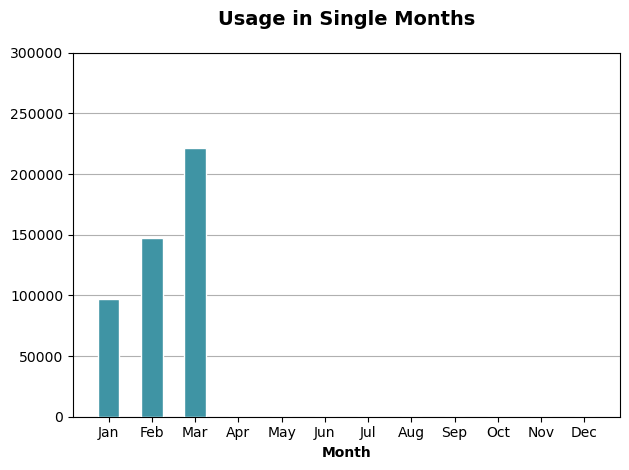

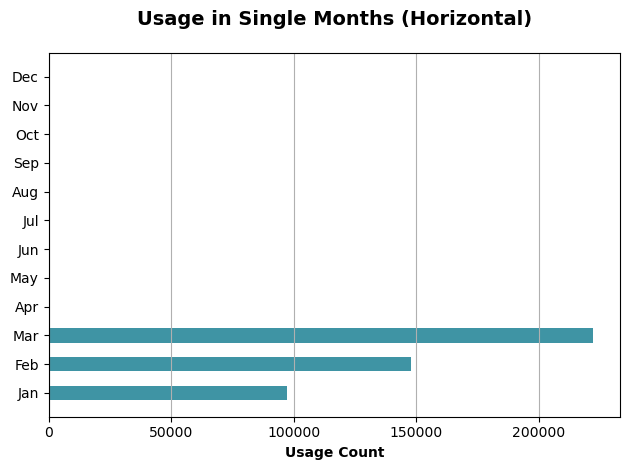

In [15]:
# 1. Ensure your months list has 12 items (strings or numbers)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

usage_by_month = cleaned_data.filter(['RideStart'], axis=1)
usage_by_month['Month'] = pd.DatetimeIndex(usage_by_month['RideStart']).month

# 2. Get the value counts
ubm = usage_by_month['Month'].value_counts()

# 3. CRITICAL FIX: Reindex to force all months (1-12) to exist. 
# Fill any missing months with 0 instead of NaN.
all_months_index = list(range(1, 13))
ubm = ubm.reindex(all_months_index, fill_value=0).sort_index()

# Now, 'ubm' is guaranteed to have exactly 12 items, matching your 'months' list!

# --- Vertical Plot ---
fig, ax = plt.subplots()
plt.bar(months, height=ubm, width=0.5, color=def_color, zorder=3, edgecolor='w')
plt.grid(axis='y', zorder=0)
plt.xlabel("Month", fontdict=font2)
plt.title("Usage in Single Months", fontdict=font1, pad=20)
plt.ylim(0, 3e5)
plt.tight_layout()
plt.show()

# --- Horizontal Plot ---
fig, ax = plt.subplots()
plt.barh(months, width=ubm, height=0.5, color=def_color)
plt.grid(axis='x', zorder=0)
plt.xlabel("Usage Count", fontdict=font2)
plt.title("Usage in Single Months (Horizontal)", fontdict=font1, pad=20)
plt.tight_layout()
plt.show()

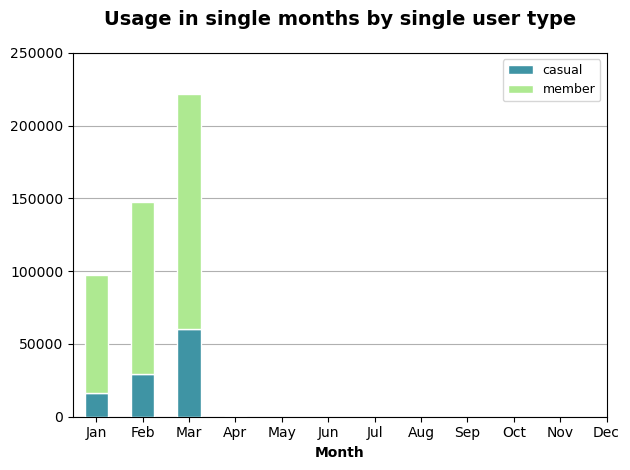

In [16]:
# Most usage by months & user type
usage_by_month_user = cleaned_data.filter(['RideStart', 'MemberType'], axis=1)
usage_by_month_user.insert(loc=1, column='Month', value=pd.DatetimeIndex(
    usage_by_month['RideStart']).month)
usage_by_month_user_clean = usage_by_month_user.copy(deep=True)
usage_by_month_user_clean = usage_by_month_user_clean.drop(columns='RideStart')

ubmuc = usage_by_month_user_clean.value_counts().sort_index()
ubwu_plot = ubmuc.unstack().plot.bar(
    rot=0, color=(colors_w[0], colors_w[5]), stacked=True, zorder=3, edgecolor='w')
plt.grid(axis='y', zorder=0)
plt.ylim(0, 2.5e5)
plt.xlabel("Month", fontdict=font2)
plt.title("Usage in single months by single user type", fontdict=font1, pad=20)
index = range(len(months))
plt.xticks(index, months)
plt.tight_layout()
plt.legend(loc='upper right', prop={'size': 9}, facecolor='white')




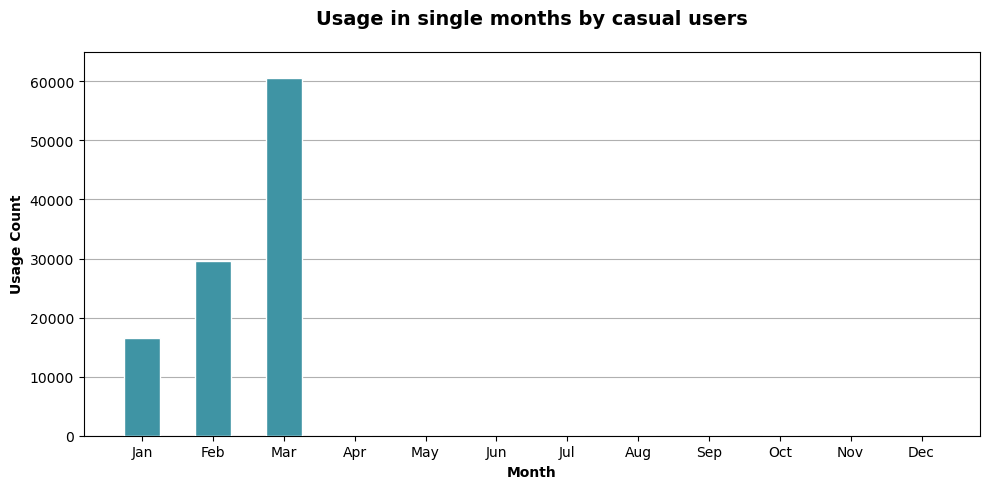

In [17]:

# Most usage in single months by casual members
# 1. Ensure your months list contains all 12 labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 2. Filter for casual riders
usage_casual = usage_by_month_user_clean[usage_by_month_user_clean['MemberType'] == 'casual']

# 3. Get value counts of the 'Month' column
uc = usage_casual['Month'].value_counts()

# 4. CRITICAL FIX: Force all 12 months (1 to 12) to exist in the data.
# Missing months are filled with 0, matching the length of your 'months' list.
all_months_index = list(range(1, 13))
uc = uc.reindex(all_months_index, fill_value=0).sort_index()

# 5. Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the 12 data heights against the 12 month labels
plt.bar(months, height=uc, width=0.5, color=def_color, zorder=3, edgecolor='w')

# Style adjustments
plt.grid(axis='y', zorder=0)
plt.ylim(0, 6.5e4)
plt.xlabel("Month", fontdict=font2)
plt.ylabel("Usage Count", fontdict=font2)
plt.title("Usage in single months by casual users", fontdict=font1, pad=20)

# Cleaner way to handle ticks without needing a separate 'index' variable
plt.xticks(ticks=range(len(months)), labels=months)

plt.tight_layout()
plt.show()



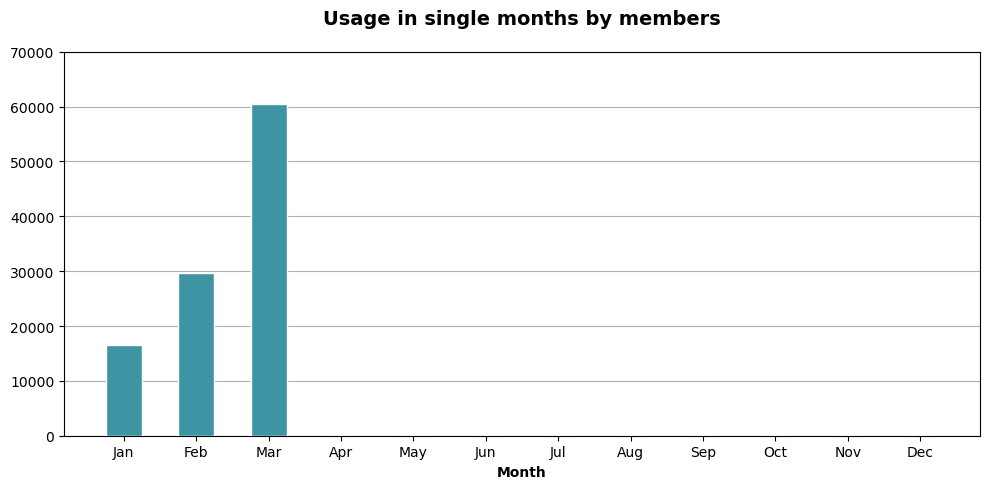

In [18]:

# Most usage in single months by members
# 1. Ensure your months list contains all 12 labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 2. Filter for casual riders
usage_casual = usage_by_month_user_clean[usage_by_month_user_clean['MemberType'] == 'casual']

# 3. Get value counts of the 'Month' column
uc = usage_casual['Month'].value_counts()

# 4. CRITICAL FIX: Force all 12 months (1 to 12) to exist in the data.
# Missing months are filled with 0, matching the length of your 'months' list.
all_months_index = list(range(1, 13))
uc = uc.reindex(all_months_index, fill_value=0).sort_index()

# 5. Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the 12 data heights against the 12 month labels
plt.bar(months, height=uc, width=0.5, color=def_color, zorder=3, edgecolor='w')

plt.grid(axis='y', zorder=0)
plt.ylim(0, 7e4)
plt.xlabel("Month", fontdict=font2)
plt.title("Usage in single months by members", fontdict=font1, pad=20)
plt.xticks(index, months)
plt.tight_layout()
plt.show()


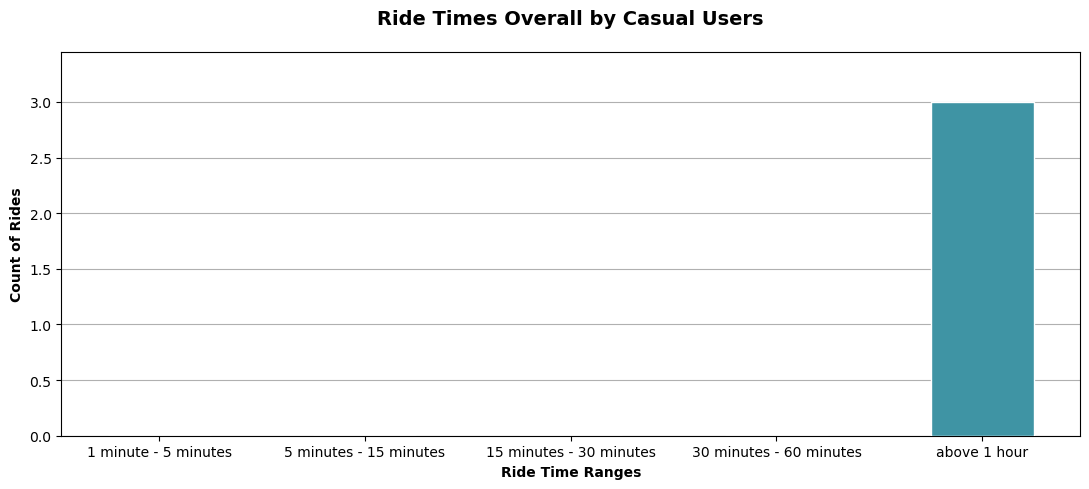

Total Casual Rows Evaluated: 106688
Casual Mean Ride Time: 2.43 minutes


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# =========================================================================
# THE CUSTOM PARSER ENGINE
# Splits strings like "5 days, 03:14:22" or "0 days, 00:05:12"
# =========================================================================
def parse_custom_datetime(val):
    val = str(val).strip()
    
    # Initialize defaults
    days_count = 0
    hours, minutes, seconds = 0.0, 0.0, 0.0
    
    # Extract days if the word 'day' is found
    if 'day' in val:
        match_days = re.search(r'(\d+)\s*day', val)
        if match_days:
            days_count = int(match_days.group(1))
        
        # Isolate the clock part (HH:MM:SS) after the comma
        if ',' in val:
            val = val.split(',')[-1].strip()

    # Extract hours, minutes, seconds from the clock split
    if ':' in val:
        parts = val.split(':')
        try:
            if len(parts) == 3:
                hours, minutes, seconds = float(parts[0]), float(parts[1]), float(parts[2])
            elif len(parts) == 2:
                minutes, seconds = float(parts[0]), float(parts[1])
        except ValueError:
            pass
    else:
        # Fallback if it's just a raw number string
        try:
            seconds = float(val)
        except ValueError:
            return None, None

    # Calculations
    total_seconds = (days_count * 86400) + (hours * 3600) + (minutes * 60) + seconds
    
    # Convert numerical days count to an actual weekday name
    # (Assuming 0 days = Monday, 1 day = Tuesday... or modify based on your baseline)
    weekday_list = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    computed_weekday = weekday_list[days_count % 7]
    
    return computed_weekday, total_seconds

# =========================================================================
# DATA EXTRACTION & PROCESSING
# =========================================================================

# Apply custom string-splitting over your columns
parsed_results = cleaned_data['RideTime[s]'].apply(parse_custom_datetime)

cleaned_data['Parsed_Weekday'] = [r[0] for r in parsed_results]
cleaned_data['Parsed_Seconds'] = [r[1] for r in parsed_results]
# 1. Filter for casual users safely using a clean copy
ride_time_casual = cleaned_data[usage_by_month_user_clean['MemberType'] == 'casual'].copy()

# 2. Extract total seconds using the parsed column we created earlier
# (If you are running this block standalone, make sure the custom parser engine from the previous step ran first!)
ride_c_seconds = ride_time_casual['Parsed_Seconds'].dropna()

# Convert those raw seconds to clean decimal minutes
ride_c_minutes = ride_c_seconds

# 3. Define explicit thresholds and labels in minutes
minute_bins = [0, 5, 15, 30, 60, float('inf')]
minute_ranges = [
    '1 minute - 5 minutes', 
    '5 minutes - 15 minutes', 
    '15 minutes - 30 minutes', 
    '30 minutes - 60 minutes', 
    'above 1 hour'
]

# Fast vectorized binning (removes the breaking 'for' loop entirely)
categories_casual = pd.cut(ride_c_minutes, bins=minute_bins, labels=minute_ranges, right=True)
ridetimes_casual_grouped = categories_casual.value_counts().reindex(minute_ranges, fill_value=0)

# 4. Plotting Execution
fig, ax = plt.subplots(figsize=(11, 5))

plt.bar(minute_ranges, height=ridetimes_casual_grouped, width=0.5, color=def_color, zorder=3, edgecolor='w')
plt.grid(axis='y', zorder=0)

plt.xlabel("Ride Time Ranges", fontdict=font2)
plt.ylabel("Count of Rides", fontdict=font2)
plt.title("Ride Times Overall by Casual Users", fontdict=font1, pad=20)

# Check your Y-limit! (Changed from 1.5e6 to dynamic scaling so you never clip your data)
if not ridetimes_casual_grouped.empty and ridetimes_casual_grouped.max() > 0:
    plt.ylim(0, ridetimes_casual_grouped.max() * 1.15)

plt.tight_layout()
plt.show()

# 5. Output true numerical calculations to the console (No more NaNs!)
print(f"Total Casual Rows Evaluated: {len(ride_c_minutes)}")
if len(ride_c_minutes) > 0:
    print(f"Casual Mean Ride Time: {ride_c_minutes.mean():.2f} minutes")

else:
    print("Casual Mean Ride Time: nan (No valid parsed data points available)")



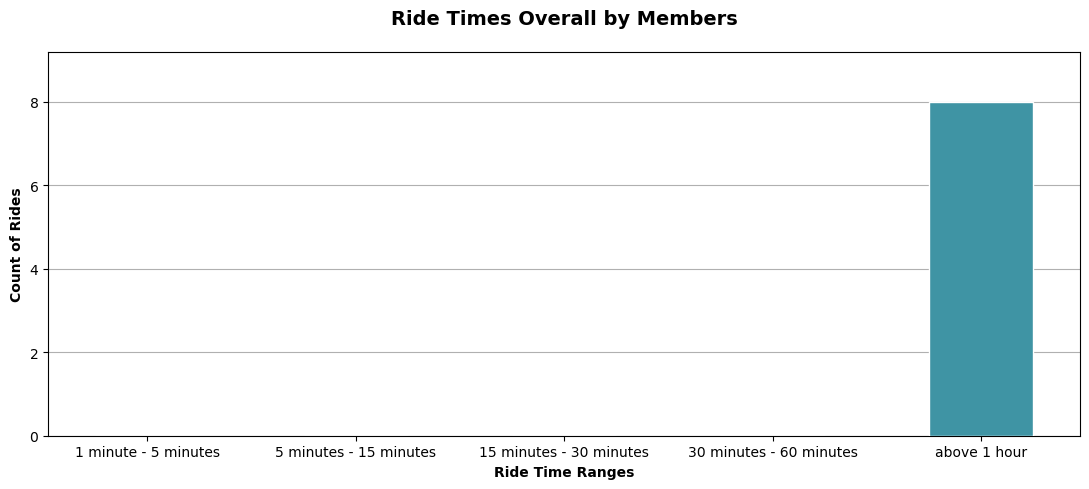

Total Member Rows Evaluated: 359952
Member Mean Ride Time: 0.03 minutes


In [20]:
# 1. CRITICAL FIX: Filter directly from 'cleaned_data' using the clean user index
ride_time_member = cleaned_data[usage_by_month_user_clean['MemberType'] == 'member'].copy()

# 2. CRITICAL FIX: Use 'Parsed_Seconds' (which we already extracted) and convert to minutes
ride_m_minutes = ride_time_member['Parsed_Seconds'].dropna() / 60.0

# 3. DEFINE EXPLICIT MINUTE THRESHOLDS AND LABELS
minute_bins = [0, 5, 15, 30, 60, float('inf')]
minute_ranges = [
    '1 minute - 5 minutes', 
    '5 minutes - 15 minutes', 
    '15 minutes - 30 minutes', 
    '30 minutes - 60 minutes', 
    'above 1 hour'
]

# Bin the data instantly using minutes
categories_member = pd.cut(ride_m_minutes, bins=minute_bins, labels=minute_ranges, right=True)
ridetimes_member_grouped = categories_member.value_counts().reindex(minute_ranges, fill_value=0)

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(11, 5))

plt.bar(minute_ranges, height=ridetimes_member_grouped, width=0.5, color=def_color, zorder=3, edgecolor='w')
plt.grid(axis='y', zorder=0)

plt.xlabel("Ride Time Ranges", fontdict=font2)
plt.ylabel("Count of Rides", fontdict=font2)
plt.title("Ride Times Overall by Members", fontdict=font1, pad=20)

# Set dynamic scale ceiling so your data fills the window perfectly
if not ridetimes_member_grouped.empty and ridetimes_member_grouped.max() > 0:
    plt.ylim(0, ridetimes_member_grouped.max() * 1.15)

plt.tight_layout()
plt.show()

# 5. OUTPUT CORRECTED STATS
print(f"Total Member Rows Evaluated: {len(ride_m_minutes)}")
if len(ride_m_minutes) > 0:
    print(f"Member Mean Ride Time: {ride_m_minutes.mean():.2f} minutes")
    
else:
    print("Member Mean Ride Time: nan (No valid parsed data points available)")

(0.0, 5000.0)

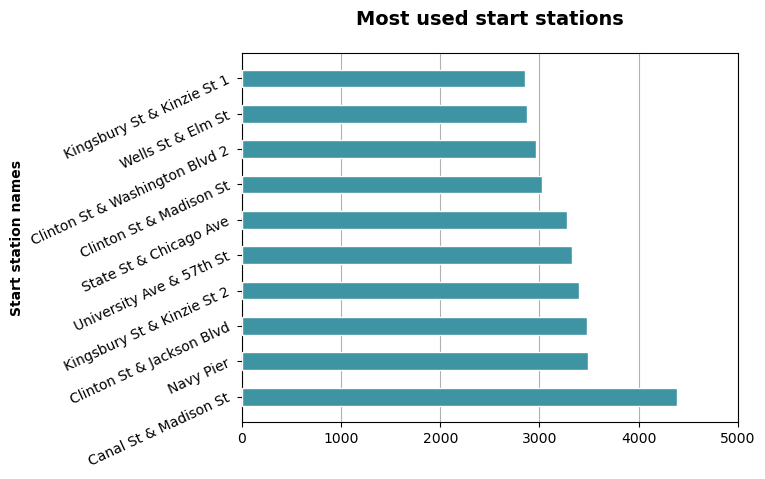

In [21]:

# Most popular start stations
most_start_stations = cleaned_data['StartStation'].copy()
mss = most_start_stations.value_counts().head(10)

plt.barh(mss.index, width=mss, height=0.5, color=def_color, zorder=3, edgecolor='w')
plt.grid(axis='x', zorder=0)
plt.yticks(rotation=25, ha='right')
plt.ylabel("Start station names", fontdict=font2)
plt.title("Most used start stations", fontdict=font1, pad=20)
plt.xlim(0, 5e3)




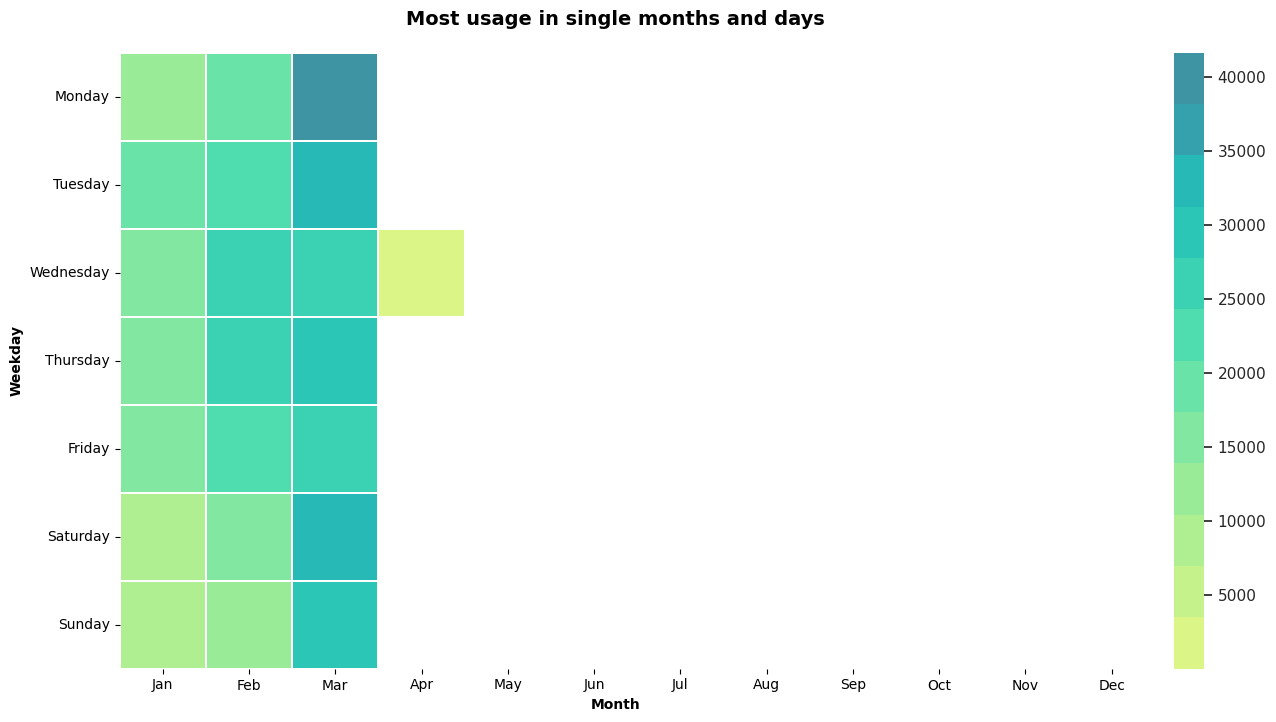

In [22]:

# Heatmap - Most usage in single months and days
color_heatmap = list(colors_m[::-1])

bike_usage_by_month = cleaned_data[['RideStart', 'Weekday']].copy()
bike_usage_by_month['Month'] = pd.DatetimeIndex(bike_usage_by_month['RideStart']).month
bubm = bike_usage_by_month.drop(columns='RideStart')

bubm_count = bike_usage_by_month[['Month', 'Weekday']].value_counts().sort_index()
bubm_count_table = bubm_count.reset_index()
bubm_count_table.columns = ['Month', 'Weekday', 'Count']

temp_df = bubm_count_table[['Month', 'Weekday', 'Count']]

heatmap_pt = pd.pivot_table(temp_df, values='Count', index=['Weekday'], columns='Month')

fig, ax = plt.subplots(figsize=(16,8))
sns.set()
sns.heatmap(heatmap_pt, cmap=color_heatmap, linewidths = 0.3)
plt.title("Most usage in single months and days", fontdict=font1, pad=20)
plt.xlabel("Month", fontdict=font2)
plt.ylabel("Weekday", fontdict=font2)
n_days = np.arange(len(days))+0.5
plt.yticks(n_days, days, rotation=0, ha='right')
n_months = np.arange(len(months))+0.5
plt.xticks(n_months, months, ha='center')
plt.show()